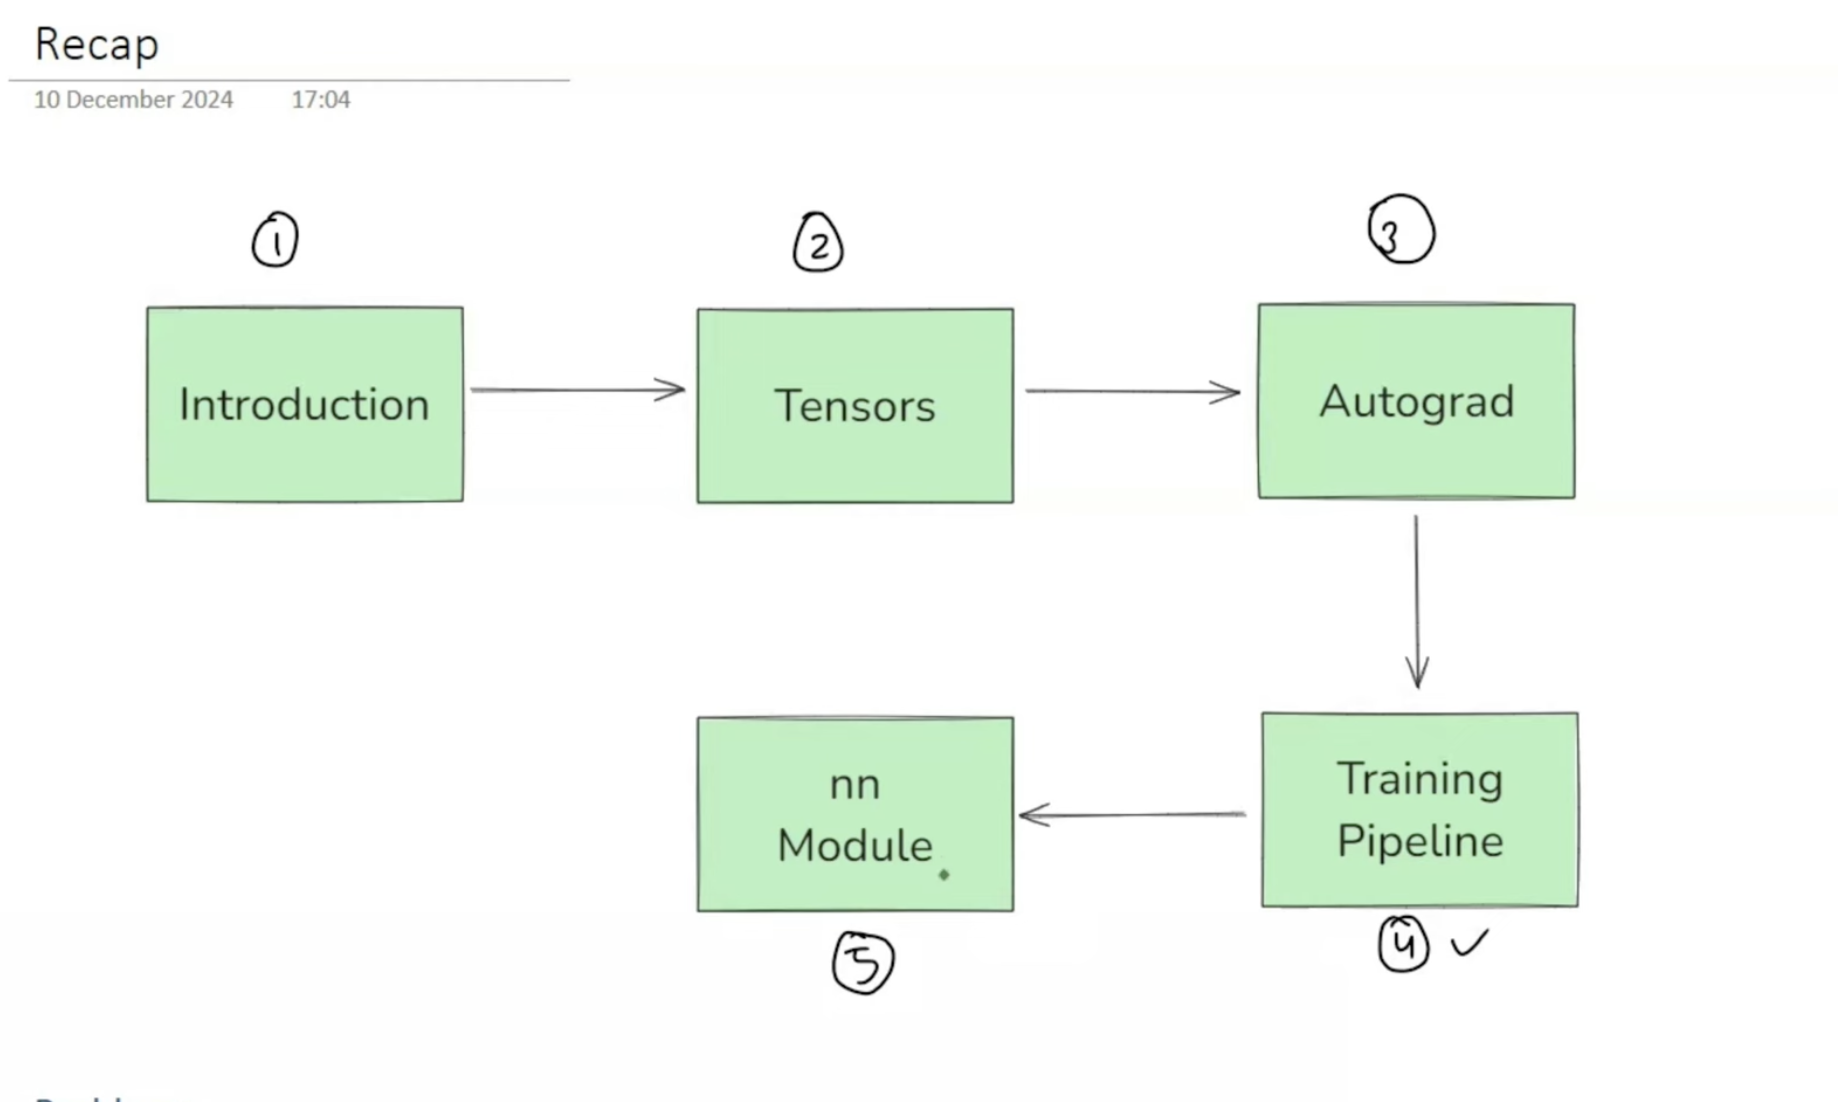

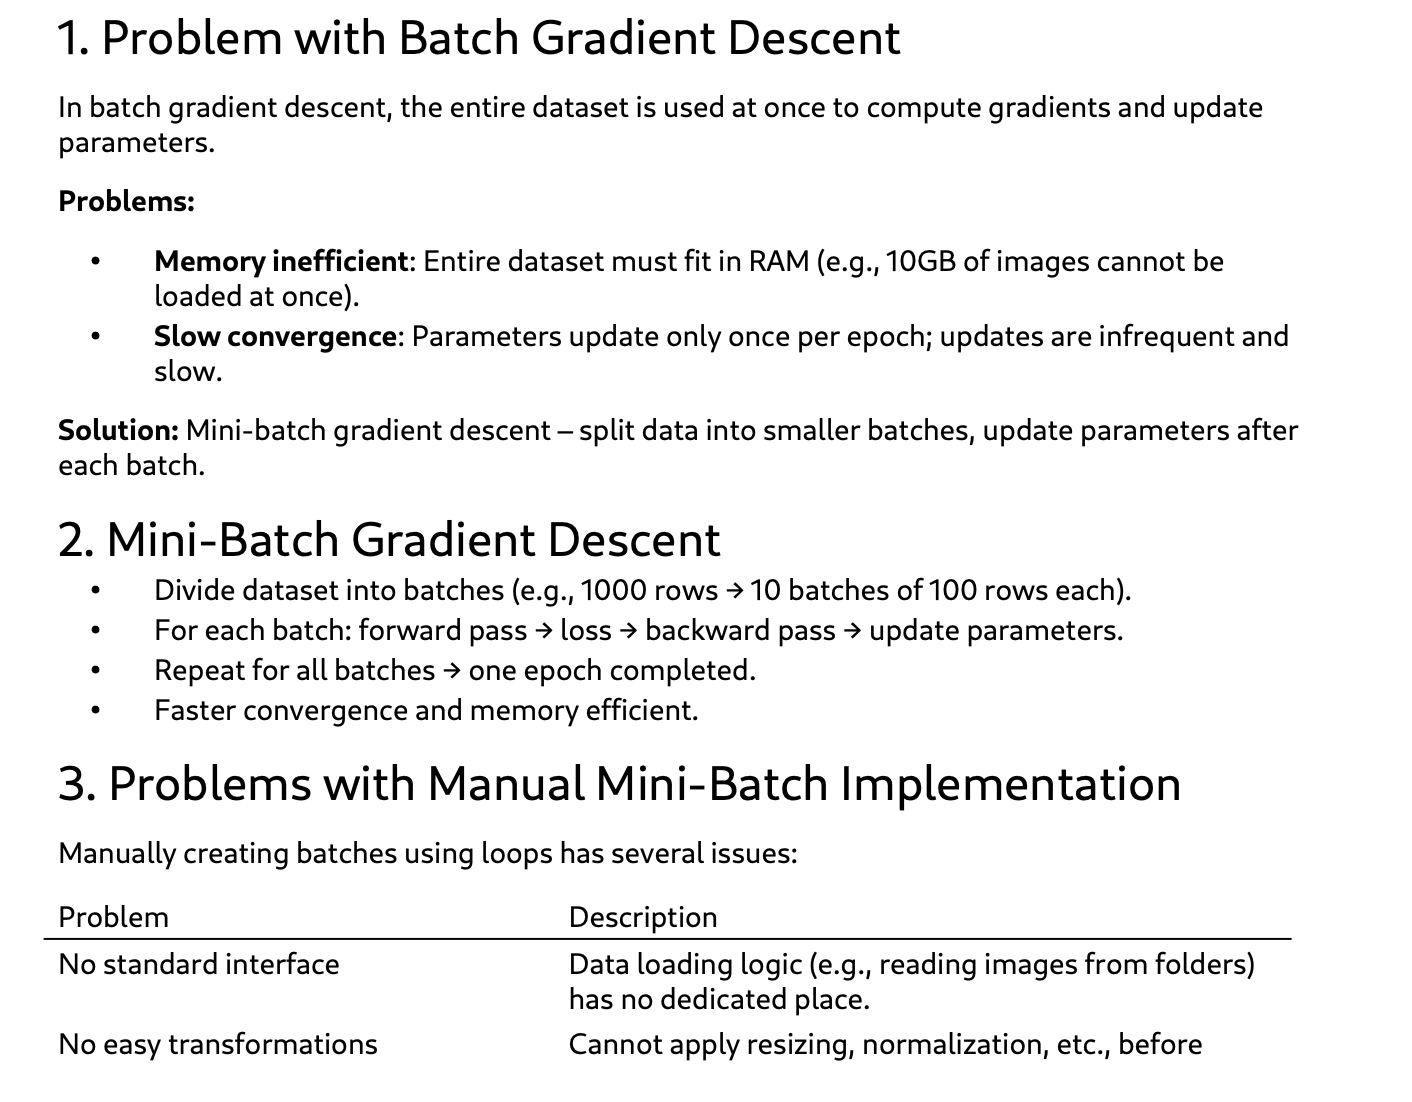

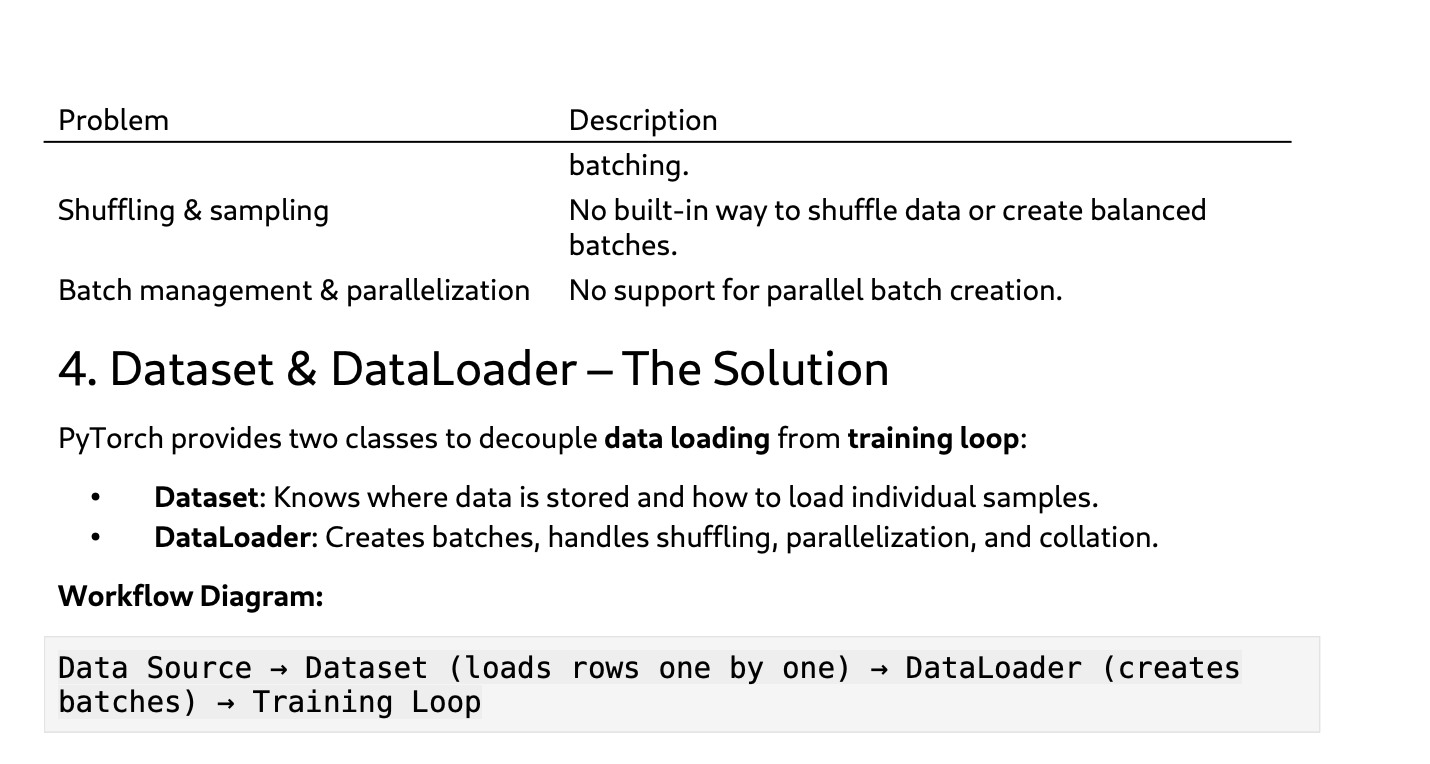

In [37]:
from sklearn.datasets import make_classification
import torch

In [38]:
X,y=make_classification(
    n_samples=10, # Number of samples
    n_features=2, #Number of features
    n_informative=2,#Number of informative features
    n_redundant=0,#Number of redundant features
    n_classes=2,#Number of classes
    random_state=42, #For Reproducibility
)

In [39]:
X

array([[ 1.06833894, -0.97007347],
       [-1.14021544, -0.83879234],
       [-2.8953973 ,  1.97686236],
       [-0.72063436, -0.96059253],
       [-1.96287438, -0.99225135],
       [-0.9382051 , -0.54304815],
       [ 1.72725924, -1.18582677],
       [ 1.77736657,  1.51157598],
       [ 1.89969252,  0.83444483],
       [-0.58723065, -1.97171753]])

In [40]:
X.shape

(10, 2)

In [41]:
y

array([1, 0, 0, 0, 0, 1, 1, 1, 1, 0])

In [42]:
y.shape

(10,)

### Convert the data to Pytorch tensors

In [43]:
from sympy.ntheory import dra


X=torch.tensor(X,dtype=torch.float32)
y=torch.tensor(y,dtype=torch.long)

In [44]:
X

tensor([[ 1.0683, -0.9701],
        [-1.1402, -0.8388],
        [-2.8954,  1.9769],
        [-0.7206, -0.9606],
        [-1.9629, -0.9923],
        [-0.9382, -0.5430],
        [ 1.7273, -1.1858],
        [ 1.7774,  1.5116],
        [ 1.8997,  0.8344],
        [-0.5872, -1.9717]])

In [45]:
y

tensor([1, 0, 0, 0, 0, 1, 1, 1, 1, 0])

## 5. Creating a Custom Dataset Class

You must inherit from **torch.utils.data.Dataset** and implement three methods

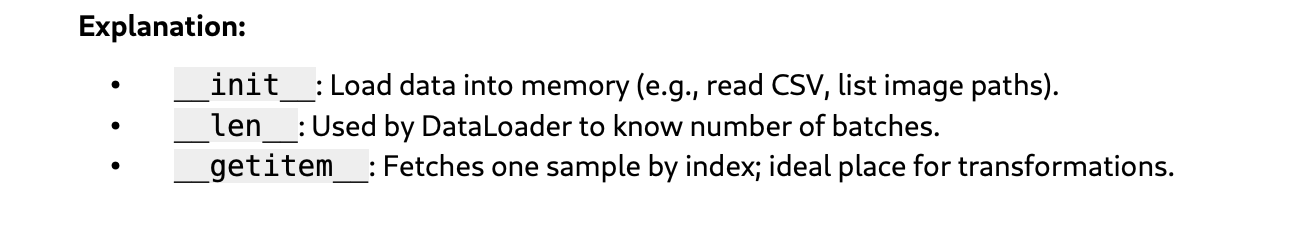

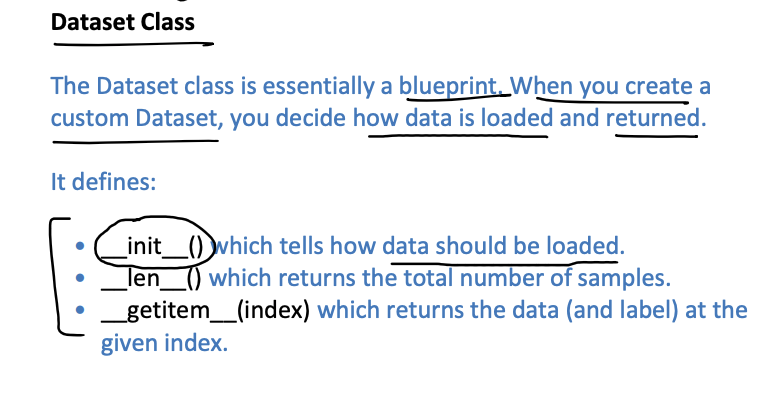

In [46]:
from torch.utils.data import Dataset

class CustomDataset(Dataset):
    def __init__(self,features,labels):
        # Constructor: load data from source (CSV, folders, etc.)
        self.features=features
        self.labels=labels
    
    def __len__(self):
        # Return total number of samples
        return len(self.features)

    
    def __getitem__ (self,index):
        # Return the sample (features, label) at given index
        # Apply transformations here if needed
        x=self.features[index]
        y=self.labels[index]

        return x,y

In [47]:
dataset=CustomDataset(features=X,labels=y)

In [48]:
len(dataset)

10

In [49]:
dataset[0]

(tensor([ 1.0683, -0.9701]), tensor(1))

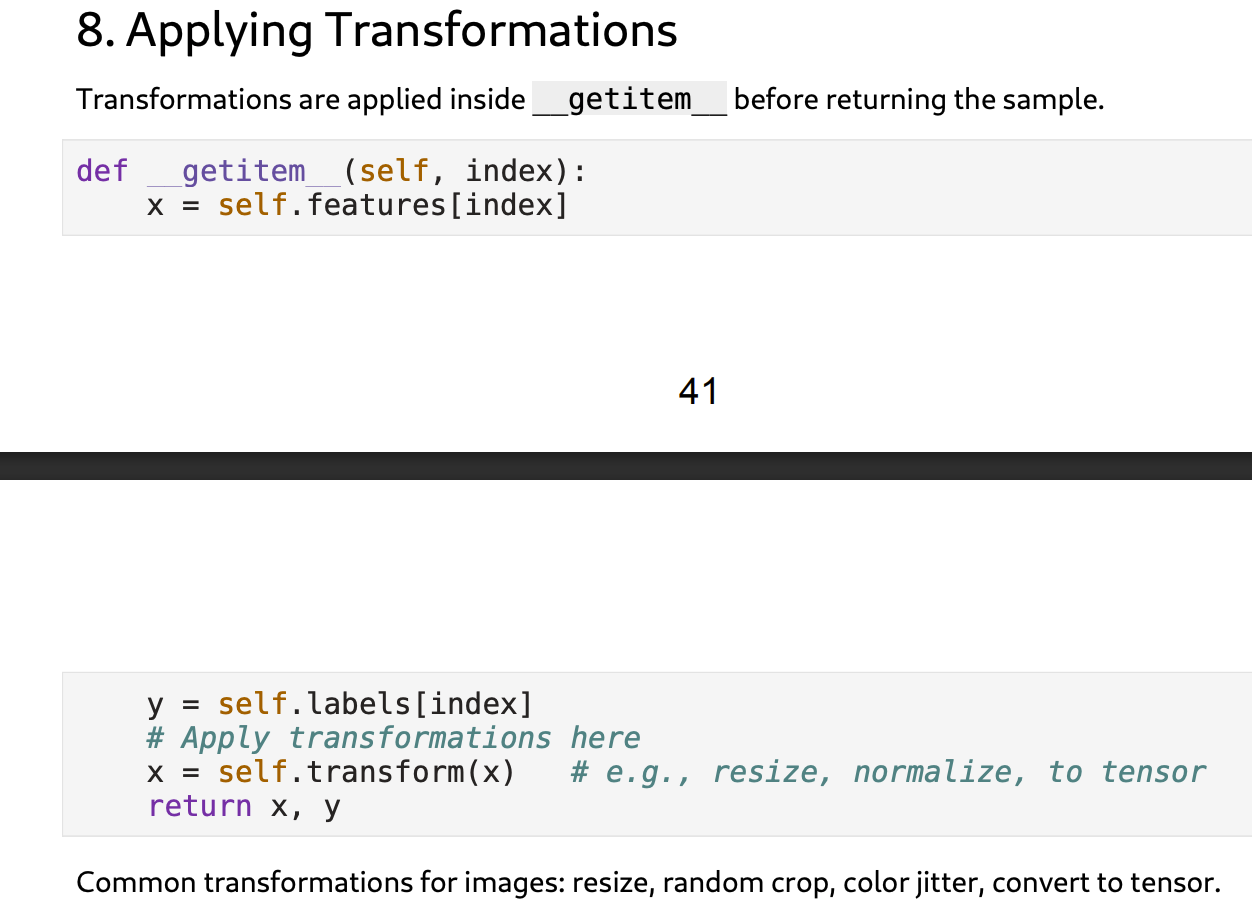

## 6. After custom Dataset class ,using DataLoader

DataLoader wraps a Dataset and provides batching,shuffling,parallel loading.

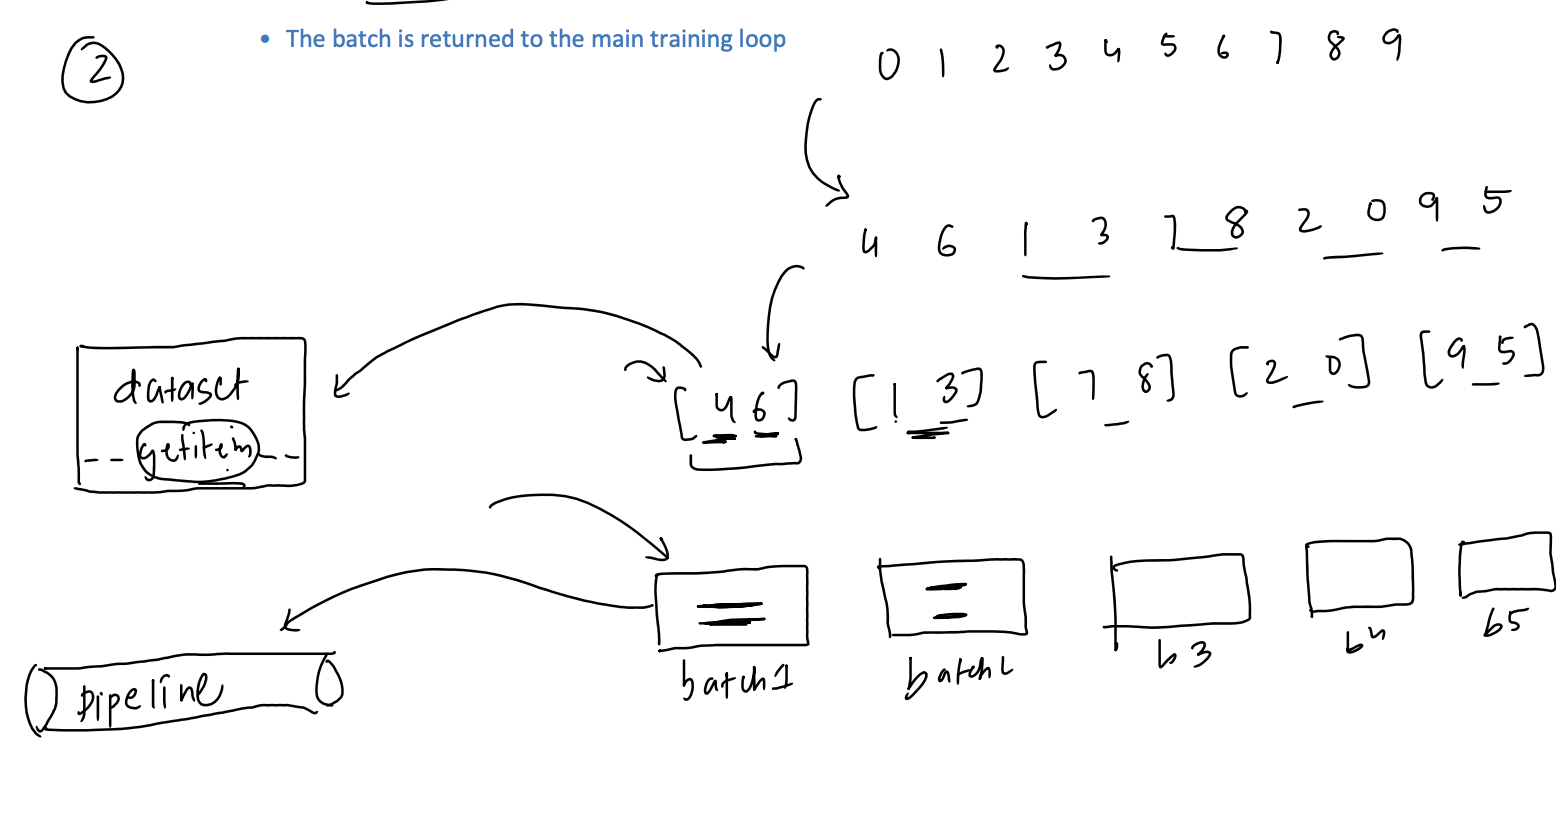

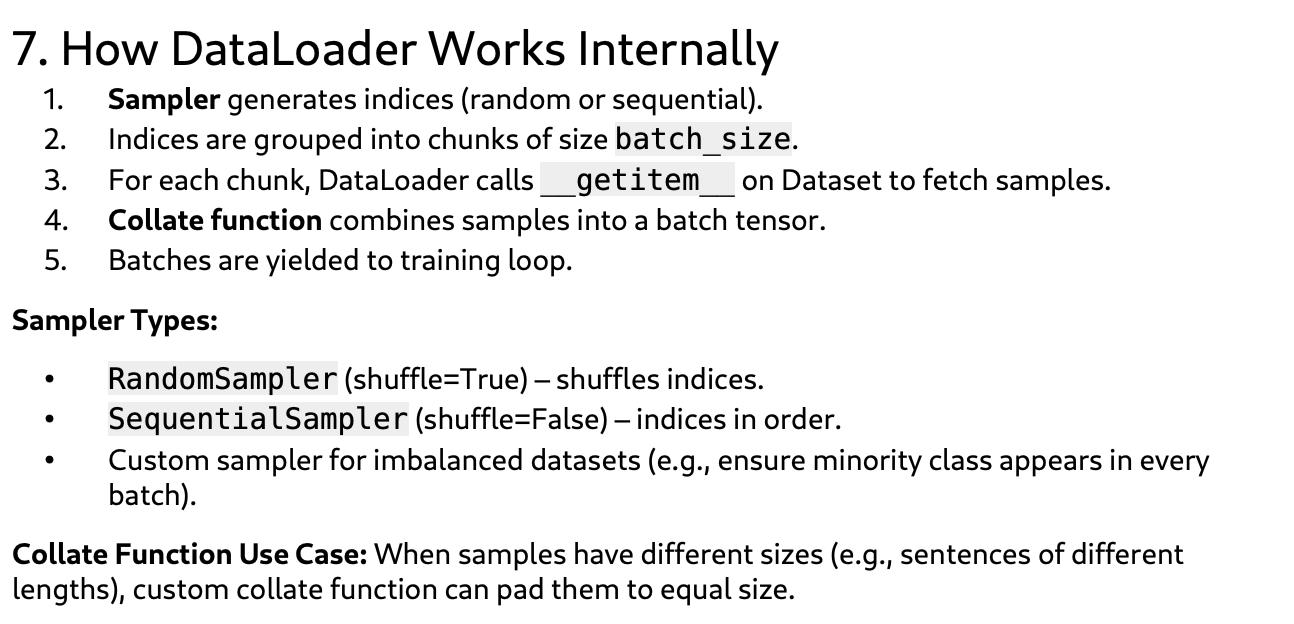

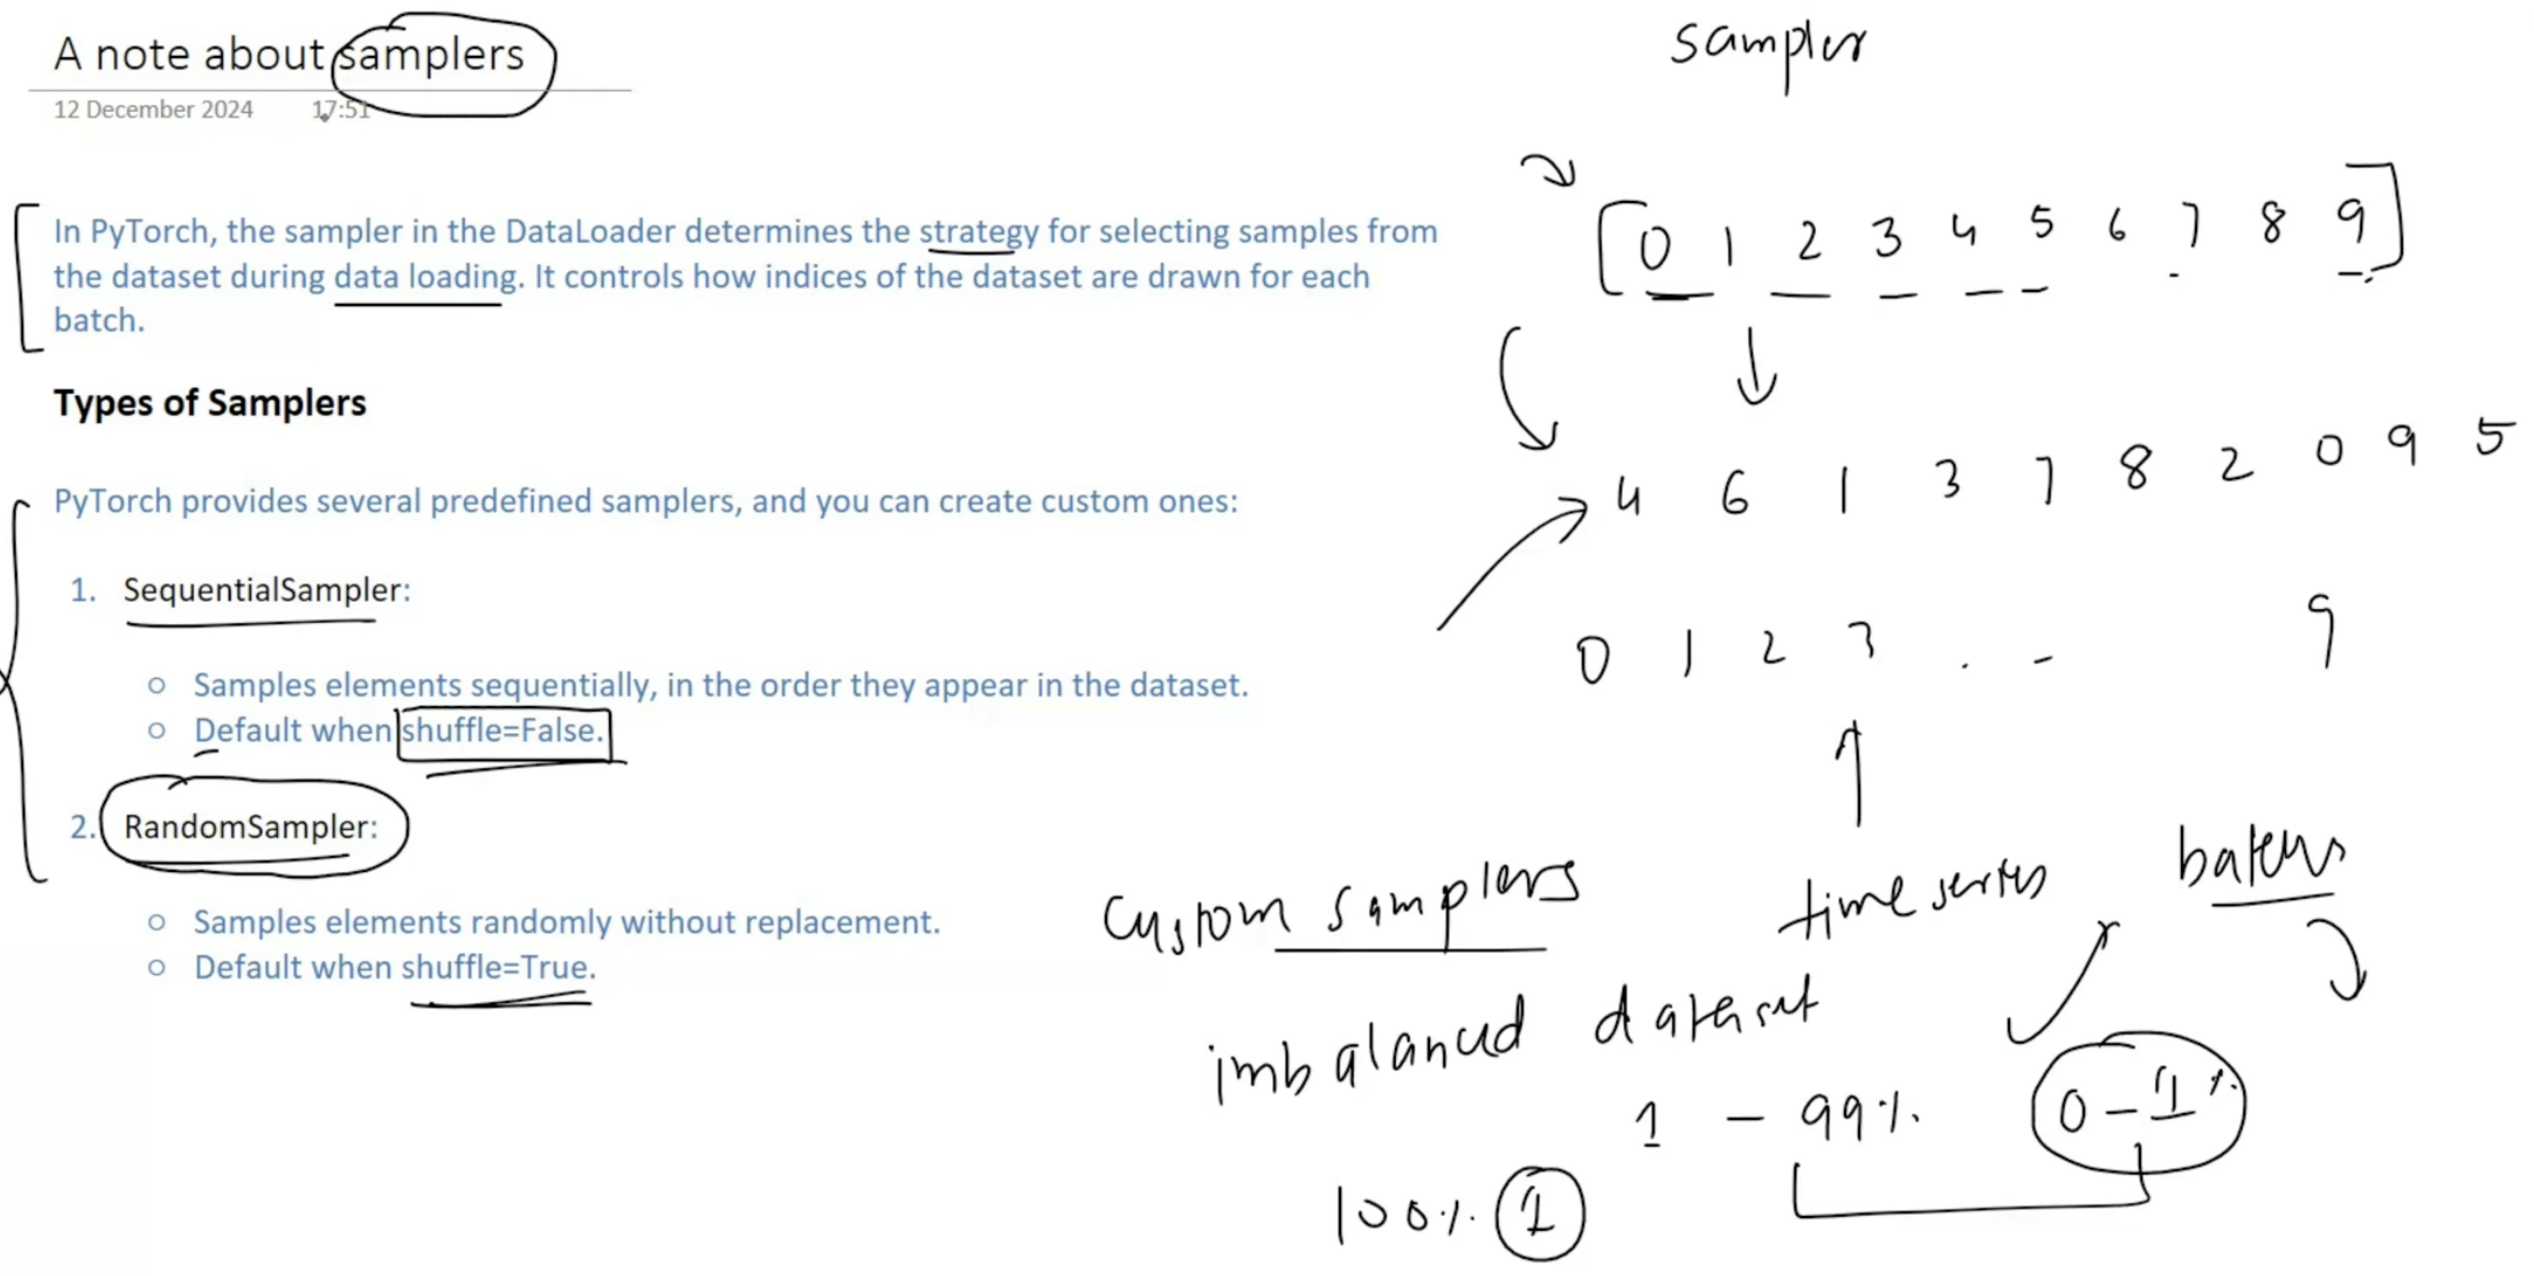

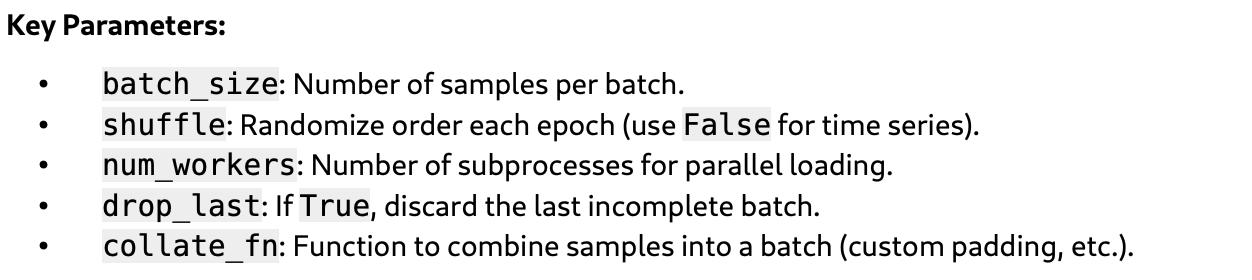

####  for no parallelization,and use of GPU


In [50]:
from torch.utils.data import DataLoader

dataloader = DataLoader(
 dataset=dataset,   # your Dataset object
 batch_size=2,            # samples per batch
 shuffle=True,             # shuffle data every epoch
)

In [51]:
# Iterate over batches

for batch_features,batch_labels in dataloader:
    print(batch_features)
    print(batch_labels)
    print("-"*50)

tensor([[ 1.0683, -0.9701],
        [ 1.7273, -1.1858]])
tensor([1, 1])
--------------------------------------------------
tensor([[-0.7206, -0.9606],
        [-1.9629, -0.9923]])
tensor([0, 0])
--------------------------------------------------
tensor([[-1.1402, -0.8388],
        [ 1.8997,  0.8344]])
tensor([0, 1])
--------------------------------------------------
tensor([[-0.9382, -0.5430],
        [ 1.7774,  1.5116]])
tensor([1, 1])
--------------------------------------------------
tensor([[-0.5872, -1.9717],
        [-2.8954,  1.9769]])
tensor([0, 0])
--------------------------------------------------


In [52]:
# Iterate over batches
for batch_idx, (batch_features, batch_labels) in enumerate(dataloader):
    print(f"Batch {batch_idx+1}:")
    print(f"Features: {batch_features}")
    print(f"Labels: {batch_labels}")
    print("---")

Batch 1:
Features: tensor([[-2.8954,  1.9769],
        [ 1.7774,  1.5116]])
Labels: tensor([0, 1])
---
Batch 2:
Features: tensor([[-0.5872, -1.9717],
        [ 1.7273, -1.1858]])
Labels: tensor([0, 1])
---
Batch 3:
Features: tensor([[-1.9629, -0.9923],
        [-1.1402, -0.8388]])
Labels: tensor([0, 0])
---
Batch 4:
Features: tensor([[ 1.0683, -0.9701],
        [-0.7206, -0.9606]])
Labels: tensor([1, 0])
---
Batch 5:
Features: tensor([[ 1.8997,  0.8344],
        [-0.9382, -0.5430]])
Labels: tensor([1, 1])
---


## for use of parallelization (Windows)

In [53]:
from torch.utils.data import DataLoader

dataloader = DataLoader(
 dataset=dataset,   # your Dataset object
 batch_size=2,            # samples per batch
 shuffle=True,             # shuffle data every epoch
 num_workers=2,           # parallel processes for loading
 pin_memory=True,          # faster GPU transfer
 drop_last=False,        # drop incomplete last batch
 collate_fn=None        # custom collation function
)

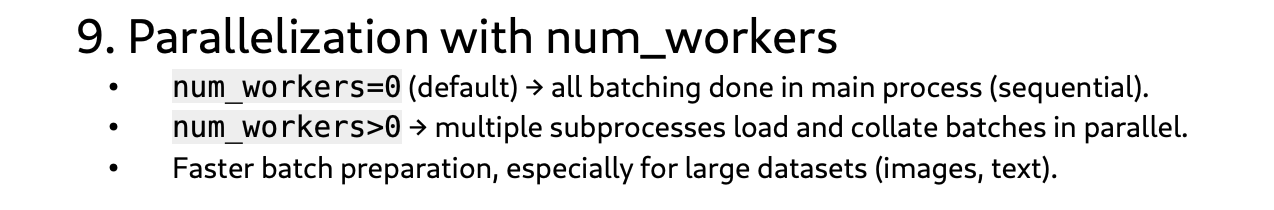

## for parallelization in mac

-- do this multiprocessing first then do as above

In [54]:
import torch.multiprocessing
torch.multiprocessing.set_start_method('spawn', force=True)

In [55]:
from torch.utils.data import DataLoader

dataloader = DataLoader(
 dataset=dataset,   # your Dataset object
 batch_size=2,            # samples per batch
 shuffle=True,             # shuffle data every epoch
 num_workers=2,           # parallel processes for loading
 pin_memory=True,          # faster GPU transfer
 drop_last=False,        # drop incomplete last batch
 collate_fn=None        # custom collation function
)

# Complete flow

In [56]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import make_classification
# Create synthetic data
X,y=make_classification(
    n_samples=10, # Number of samples
    n_features=2, #Number of features
    n_informative=2,#Number of informative features
    n_redundant=0,#Number of redundant features
    n_classes=2,#Number of classes
    random_state=42, #For Reproducibility
)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)
# Define custom Dataset
class CustomDataset(Dataset):
    def __init__(self, features, labels):
 # Constructor: load data from source (CSV, folders, etc.)
        self.features = features
        self.labels = labels

    def __len__(self):
 # Return total number of samples
        return len(self.features)

    def __getitem__(self, index):
 # Return the sample (features, label) at given index
 # Apply transformations here if needed
        x = self.features[index]
        y = self.labels[index]
        return x, y

# Create Dataset and DataLoader
dataset=CustomDataset(features=X,labels=y)
dataloader = DataLoader(
 dataset=dataset,   # your Dataset object
 batch_size=2,            # samples per batch
 shuffle=True,             # shuffle data every epoch
)
# Iterate over batches
for batch_idx, (batch_features, batch_labels) in enumerate(dataloader):
    print(f"Batch {batch_idx+1}:")
    print(f"Features: {batch_features}")
    print(f"Labels: {batch_labels}")
    print("---")

Batch 1:
Features: tensor([[ 1.8997,  0.8344],
        [ 1.7273, -1.1858]])
Labels: tensor([1, 1])
---
Batch 2:
Features: tensor([[-1.1402, -0.8388],
        [ 1.0683, -0.9701]])
Labels: tensor([0, 1])
---
Batch 3:
Features: tensor([[-0.5872, -1.9717],
        [ 1.7774,  1.5116]])
Labels: tensor([0, 1])
---
Batch 4:
Features: tensor([[-1.9629, -0.9923],
        [-0.7206, -0.9606]])
Labels: tensor([0, 0])
---
Batch 5:
Features: tensor([[-0.9382, -0.5430],
        [-2.8954,  1.9769]])
Labels: tensor([1, 0])
---


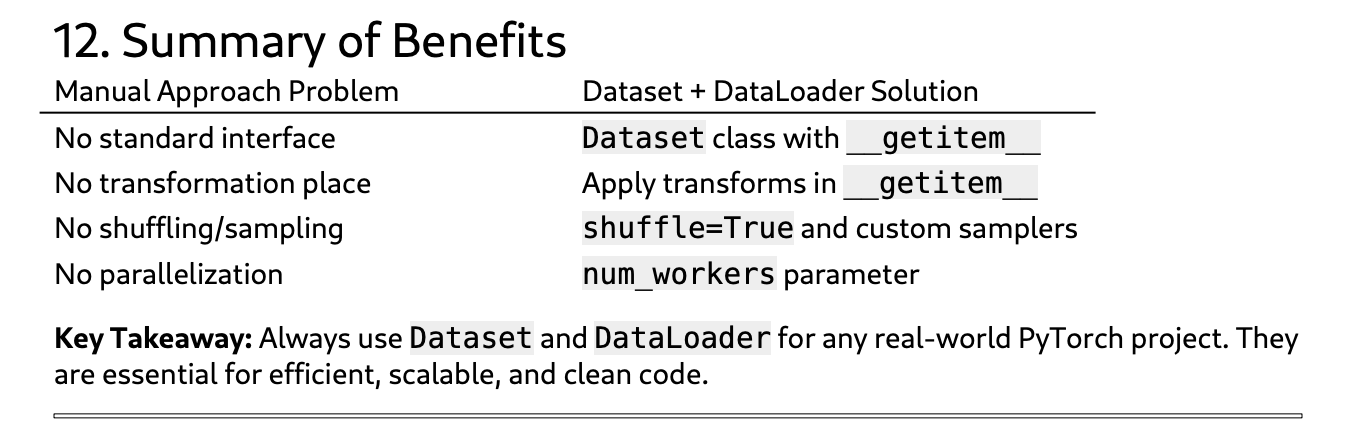